# Xây dựng CNN trên Fashion MNIST bằng PyTorch
Notebook này sử dụng PyTorch để xây dựng, huấn luyện và đánh giá mô hình CNN.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
import struct

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if not os.path.exists('../saved_models'):
    os.makedirs('../saved_models')

Using device: cuda


## 1. Load Dữ liệu

In [2]:
def load_idx_images(filename):
    with open(filename, 'rb') as f:
        magic, size, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(size, rows, cols)
    return data

def load_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train = load_idx_images('../data/train-images-idx3-ubyte')
y_train = load_idx_labels('../data/train-labels-idx1-ubyte')
X_test = load_idx_images('../data/t10k-images-idx3-ubyte')
y_test = load_idx_labels('../data/t10k-labels-idx1-ubyte')

# Chuẩn hóa
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Reshape cho PyTorch: (N, C, H, W)
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

# Tạo TensorDataset và DataLoader
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).long())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Data loaded and DataLoaders created.")

Data loaded and DataLoaders created.


C:\Users\admin\AppData\Local\Temp\ipykernel_9720\1213993783.py:27: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())


## 2. Trực quan hóa dữ liệu

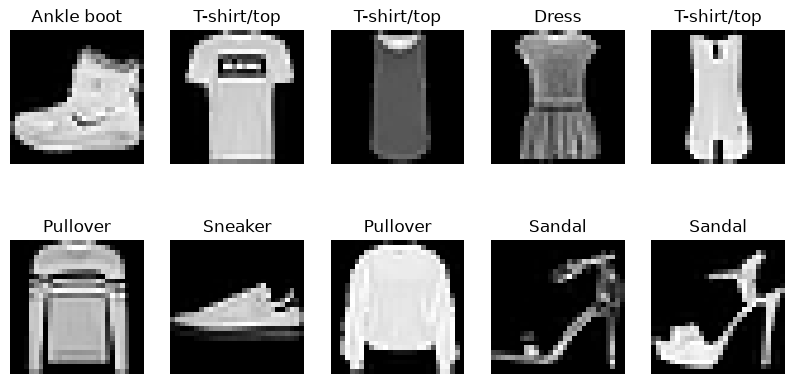

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

## 3. Định nghĩa Mô hình CNN (PyTorch)

In [4]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Huấn luyện

In [5]:
epochs = 10
train_losses = []
val_losses = []
best_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    train_losses.append(running_loss / len(train_loader))
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_losses.append(val_loss / len(test_loader))
    acc = 100 * correct / total
    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {acc:.2f}%')
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), '../saved_models/fashion_mnist_pytorch_best.pth')
        print("  -> Model saved!")

print("Training finished.")

Epoch [1/10], Train Loss: 0.5007, Val Loss: 0.3242, Val Acc: 88.10%
  -> Model saved!
Epoch [2/10], Train Loss: 0.3517, Val Loss: 0.2845, Val Acc: 89.72%
  -> Model saved!
Epoch [3/10], Train Loss: 0.3057, Val Loss: 0.2762, Val Acc: 89.47%
Epoch [4/10], Train Loss: 0.2775, Val Loss: 0.2448, Val Acc: 90.90%
  -> Model saved!
Epoch [5/10], Train Loss: 0.2554, Val Loss: 0.2429, Val Acc: 91.47%
  -> Model saved!
Epoch [6/10], Train Loss: 0.2378, Val Loss: 0.2353, Val Acc: 91.29%
Epoch [7/10], Train Loss: 0.2226, Val Loss: 0.2364, Val Acc: 91.54%
  -> Model saved!
Epoch [8/10], Train Loss: 0.2086, Val Loss: 0.2418, Val Acc: 91.11%
Epoch [9/10], Train Loss: 0.1971, Val Loss: 0.2279, Val Acc: 91.88%
  -> Model saved!
Epoch [10/10], Train Loss: 0.1864, Val Loss: 0.2411, Val Acc: 92.11%
  -> Model saved!
Training finished.


## 5. Đánh giá và Trực quan hóa

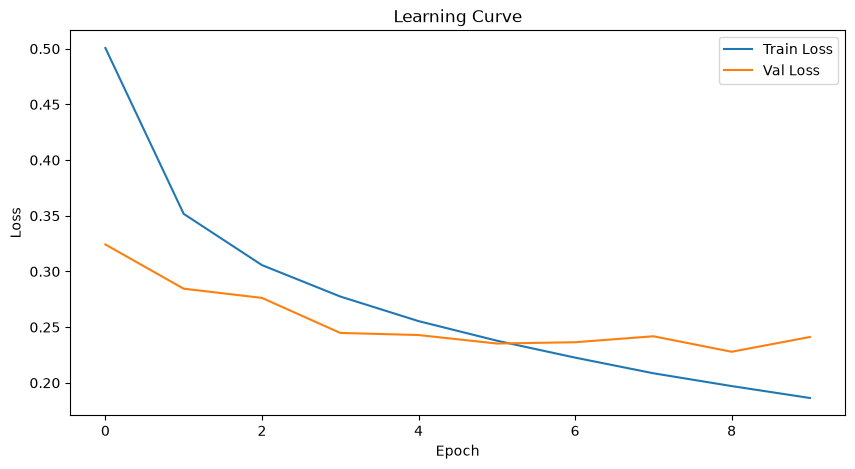

In [6]:
# Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

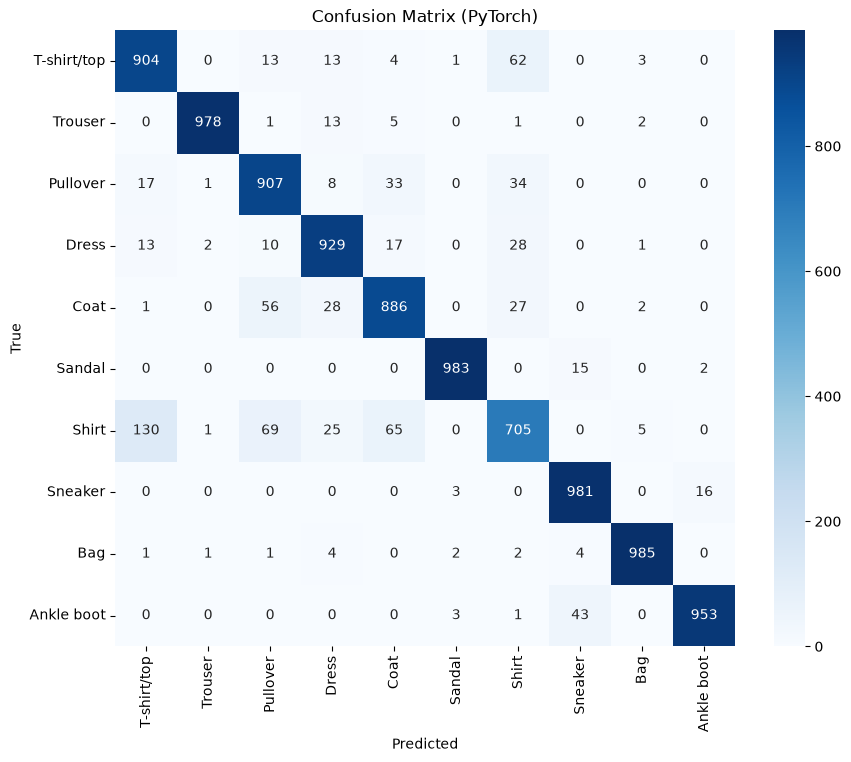

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.90      0.88      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.91      0.88      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.88      0.89      0.88      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.82      0.70      0.76      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [7]:
# Load best model để đánh giá
model.load_state_dict(torch.load('../saved_models/fashion_mnist_pytorch_best.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (PyTorch)')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

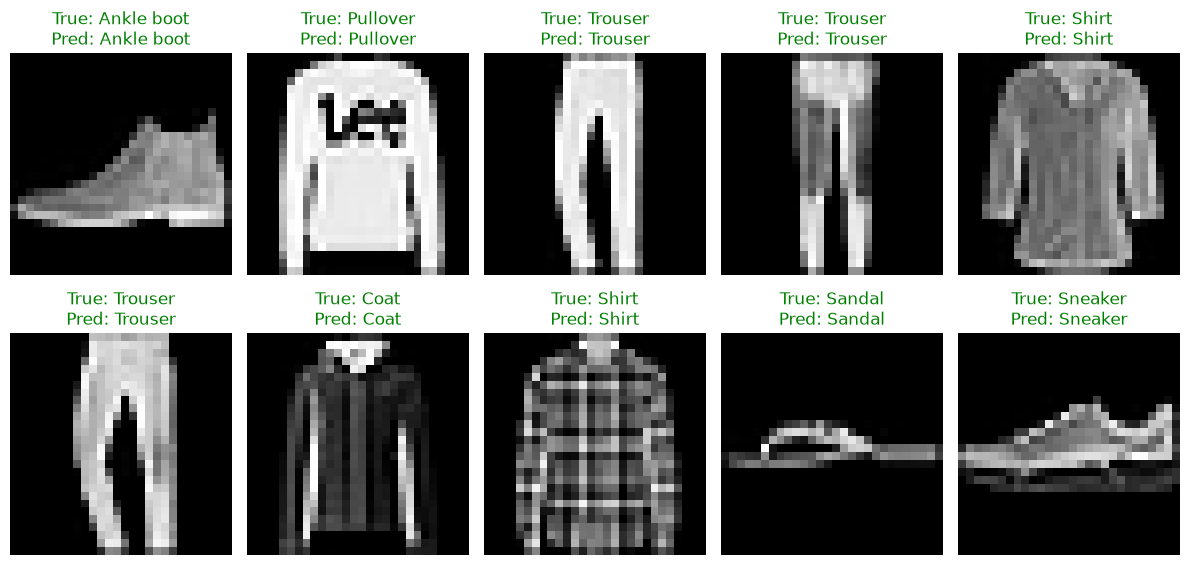

In [8]:
# Hiển thị một số dự đoán
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()